<div style="display: flex; background-color: RGB(128,0,0);" >
<h1 style="margin: auto; padding: 30px; "> P11 : Produisez une étude de marché avec R ou Python </h1>
</div>


# 1. Importation des librairies


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [35]:
#!pip install missingno 

In [36]:
import missingno as msno

# 2. Lecture des fichiers

In [4]:
dali = pd.read_csv("C:\\Users\\dchan\\Downloads\\P11OPC\\data_2df\\DisponibiliteAlimentaire_2017.csv", sep=",")
display(dali)

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.00,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.00,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.00,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.00,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.00,S,Données standardisées
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176595,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,5142,Nourriture,2899,Miscellanees,2017,2017,Milliers de tonnes,19.00,S,Données standardisées
176596,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,645,Disponibilité alimentaire en quantité (kg/pers...,2899,Miscellanees,2017,2017,kg,1.33,Fc,Donnée calculée
176597,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,664,Disponibilité alimentaire (Kcal/personne/jour),2899,Miscellanees,2017,2017,Kcal/personne/jour,1.00,Fc,Donnée calculée
176598,FBS,Nouveaux Bilans Alimentaire,181,Zimbabwe,674,Disponibilité de protéines en quantité (g/pers...,2899,Miscellanees,2017,2017,g/personne/jour,0.04,Fc,Donnée calculée


In [2]:
pop = pd.read_csv("C:\\Users\\dchan\\Downloads\\P11OPC\\data_2df\\Population_2000_2018.csv", sep=",")
display(pop)

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4406,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2014,2014,1000 personnes,13586.707,X,Sources internationales sûres,NaN
4407,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2015,2015,1000 personnes,13814.629,X,Sources internationales sûres,NaN
4408,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2016,2016,1000 personnes,14030.331,X,Sources internationales sûres,NaN
4409,OA,Séries temporelles annuelles,181,Zimbabwe,511,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,14236.595,X,Sources internationales sûres,NaN


# 3. Exploration des dfs

In [5]:

# Dimensions des fichiers
print("Taille POP :", pop.shape)
print("Taille DALI :", dali.shape)

Taille POP : (4411, 15)
Taille DALI : (176600, 14)


In [ ]:
# Aperçu des données
#pop
print("\n--- POP ---")
print(pop.head())
#supprimer la colonne Note 



--- POP ---
  Code Domaine                       Domaine  Code zone         Zone  \
0           OA  Séries temporelles annuelles          2  Afghanistan   
1           OA  Séries temporelles annuelles          2  Afghanistan   
2           OA  Séries temporelles annuelles          2  Afghanistan   
3           OA  Séries temporelles annuelles          2  Afghanistan   
4           OA  Séries temporelles annuelles          2  Afghanistan   

   Code Élément            Élément  Code Produit                 Produit  \
0           511  Population totale          3010  Population-Estimations   
1           511  Population totale          3010  Population-Estimations   
2           511  Population totale          3010  Population-Estimations   
3           511  Population totale          3010  Population-Estimations   
4           511  Population totale          3010  Population-Estimations   

   Code année  Année           Unité     Valeur Symbole  \
0        2000   2000  1000 personnes  

In [ ]:
#dali
print("\n--- DALI ---")
print(dali.head())
#supprimer la colonne Note 


--- DALI ---
  Code Domaine                      Domaine  Code zone         Zone  \
0          FBS  Nouveaux Bilans Alimentaire          2  Afghanistan   
1          FBS  Nouveaux Bilans Alimentaire          2  Afghanistan   
2          FBS  Nouveaux Bilans Alimentaire          2  Afghanistan   
3          FBS  Nouveaux Bilans Alimentaire          2  Afghanistan   
4          FBS  Nouveaux Bilans Alimentaire          2  Afghanistan   

   Code Élément                   Élément  Code Produit          Produit  \
0          5511                Production          2511  Blé et produits   
1          5611   Importations - Quantité          2511  Blé et produits   
2          5072        Variation de stock          2511  Blé et produits   
3          5911   Exportations - Quantité          2511  Blé et produits   
4          5301  Disponibilité intérieure          2511  Blé et produits   

   Code année  Année               Unité  Valeur Symbole  \
0        2017   2017  Milliers de tonnes  

In [11]:

# colonnes pop 
print("\nColonnes POP :", pop.columns.tolist())



Colonnes POP : ['Code Domaine', 'Domaine', 'Code zone', 'Zone', 'Code Élément', 'Élément', 'Code Produit', 'Produit', 'Code année', 'Année', 'Unité', 'Valeur', 'Symbole', 'Description du Symbole', 'Note']


In [10]:
# colonnes dali
print("Colonnes DALI :", dali.columns.tolist())

Colonnes DALI : ['Code Domaine', 'Domaine', 'Code zone', 'Zone', 'Code Élément', 'Élément', 'Code Produit', 'Produit', 'Code année', 'Année', 'Unité', 'Valeur', 'Symbole', 'Description du Symbole']


In [12]:

# valeurs manquantes pop
print("\nValeurs manquantes POP :\n", pop.isnull().sum())



Valeurs manquantes POP :
 Code Domaine                 0
Domaine                      0
Code zone                    0
Zone                         0
Code Élément                 0
Élément                      0
Code Produit                 0
Produit                      0
Code année                   0
Année                        0
Unité                        0
Valeur                       0
Symbole                      0
Description du Symbole       0
Note                      4153
dtype: int64


In [13]:
# valeurs manquantes dali
print("\nValeurs manquantes DALI :\n", dali.isnull().sum())


Valeurs manquantes DALI :
 Code Domaine              0
Domaine                   0
Code zone                 0
Zone                      0
Code Élément              0
Élément                   0
Code Produit              0
Produit                   0
Code année                0
Année                     0
Unité                     0
Valeur                    0
Symbole                   0
Description du Symbole    0
dtype: int64


# 3-b Visualize missing data

<Axes: >

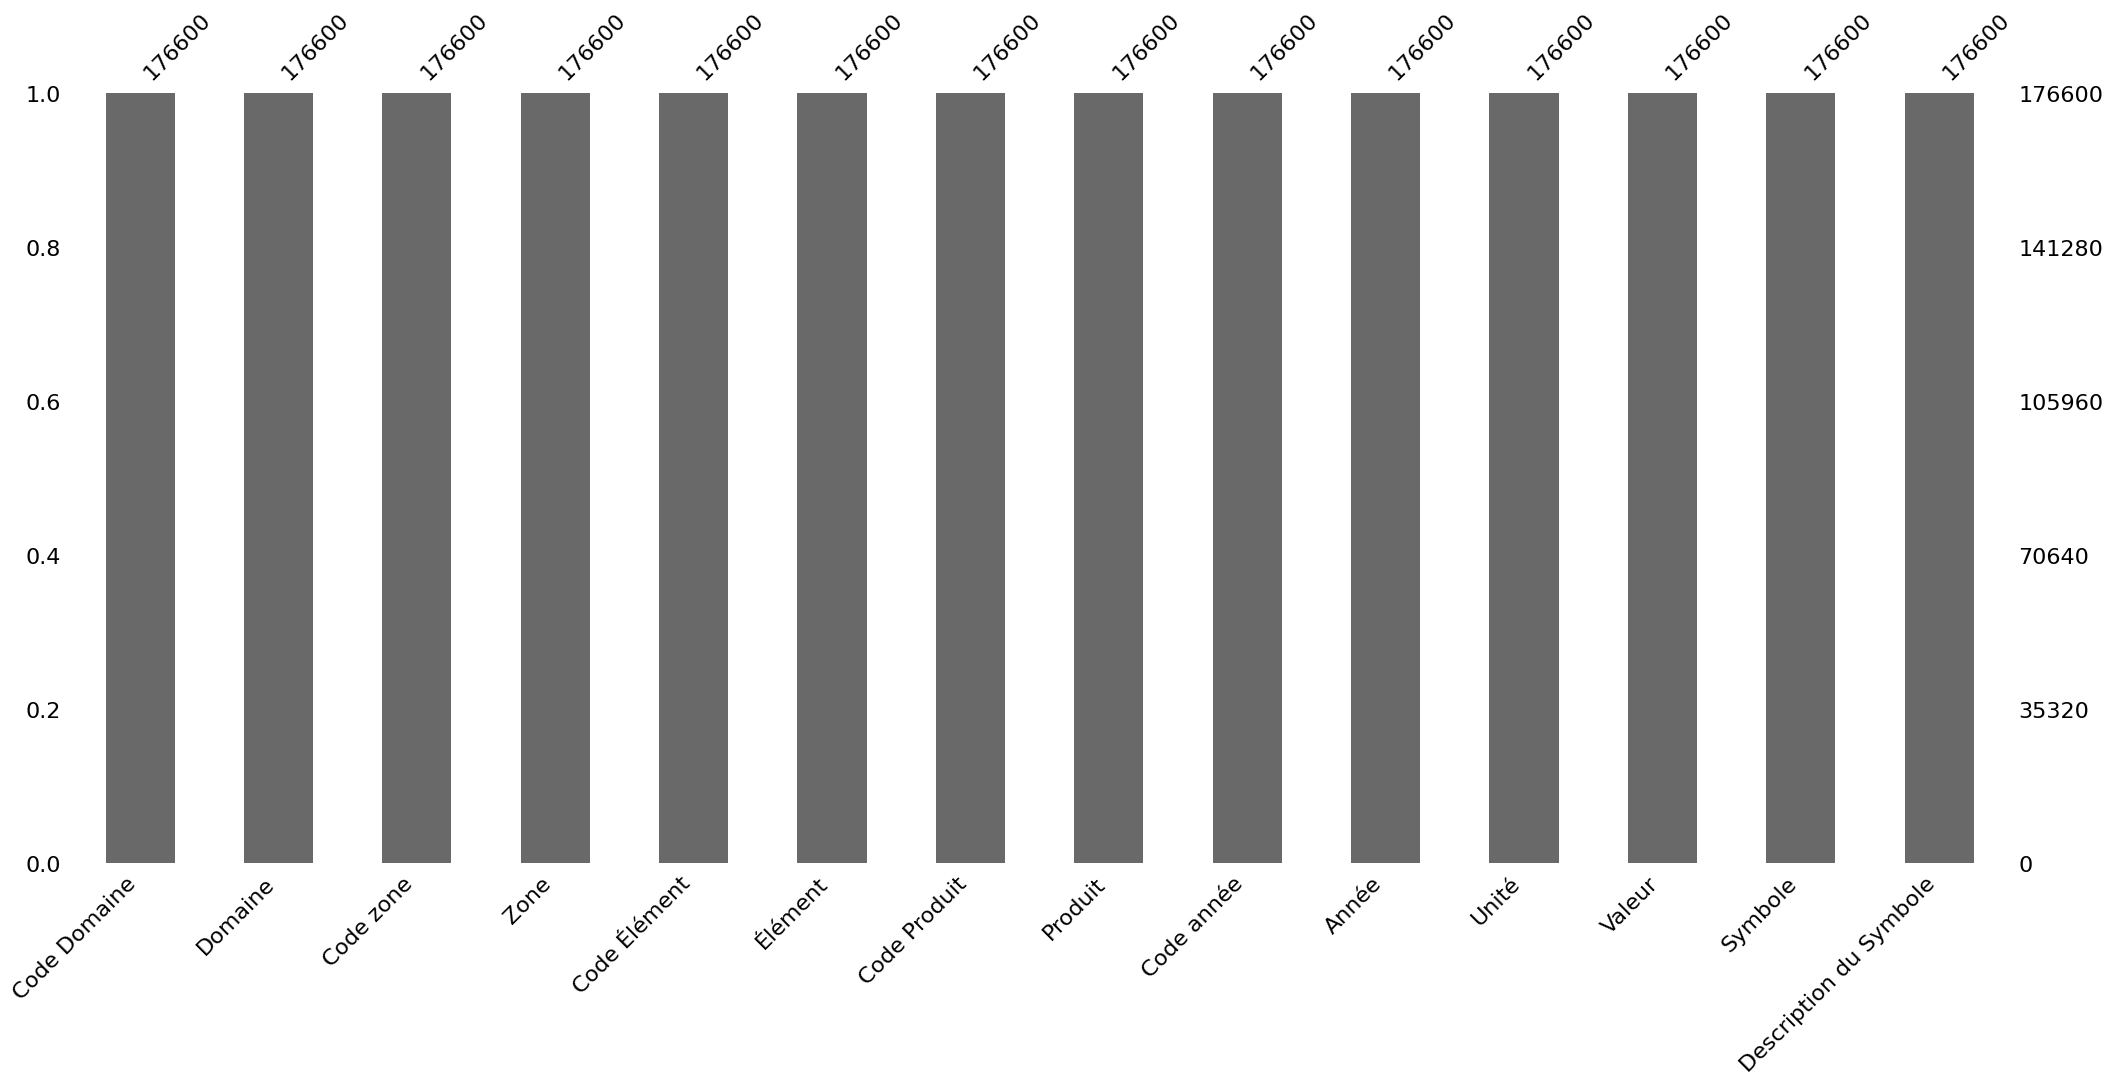

In [37]:
msno.bar(dali)         # Bar chart

<Axes: >

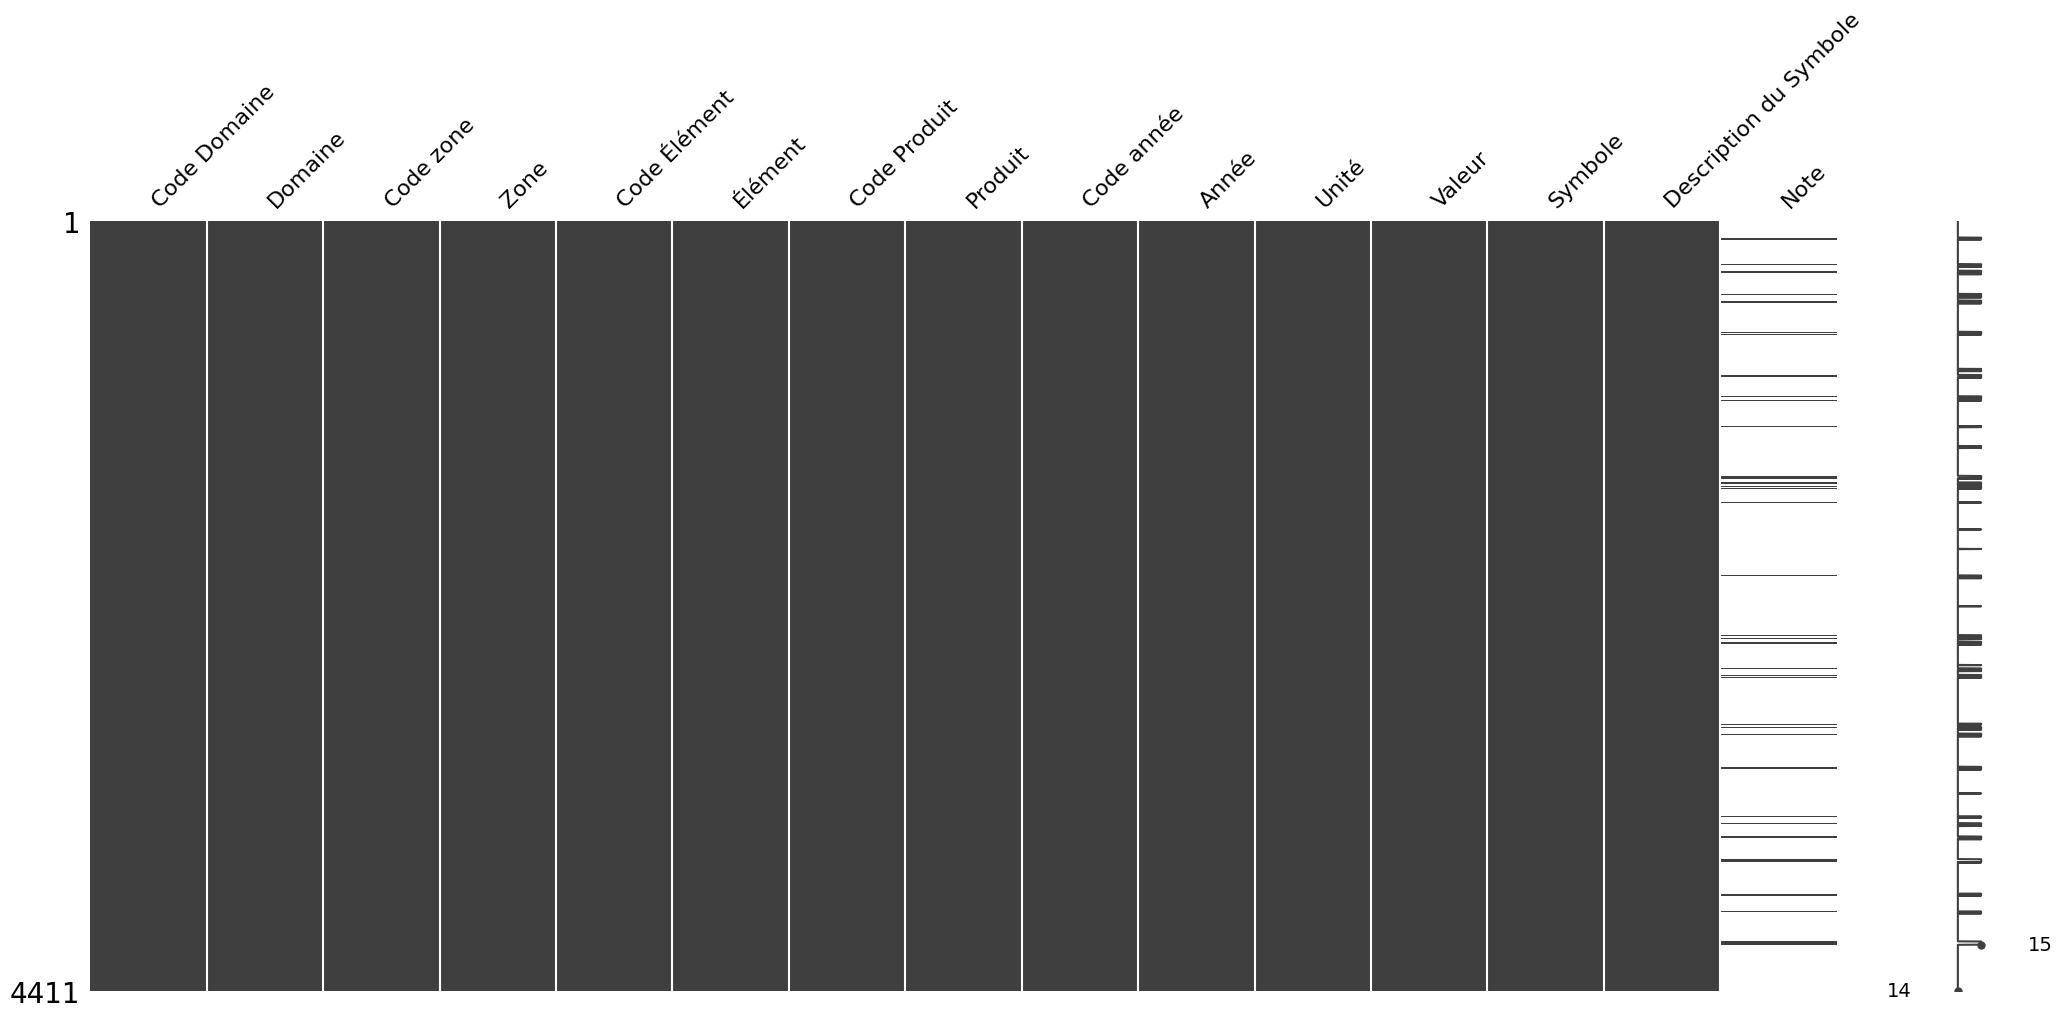

In [38]:
msno.matrix(pop)      # Matrix plot

c:\Users\dchan\miniconda3\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
c:\Users\dchan\miniconda3\lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


<Axes: >

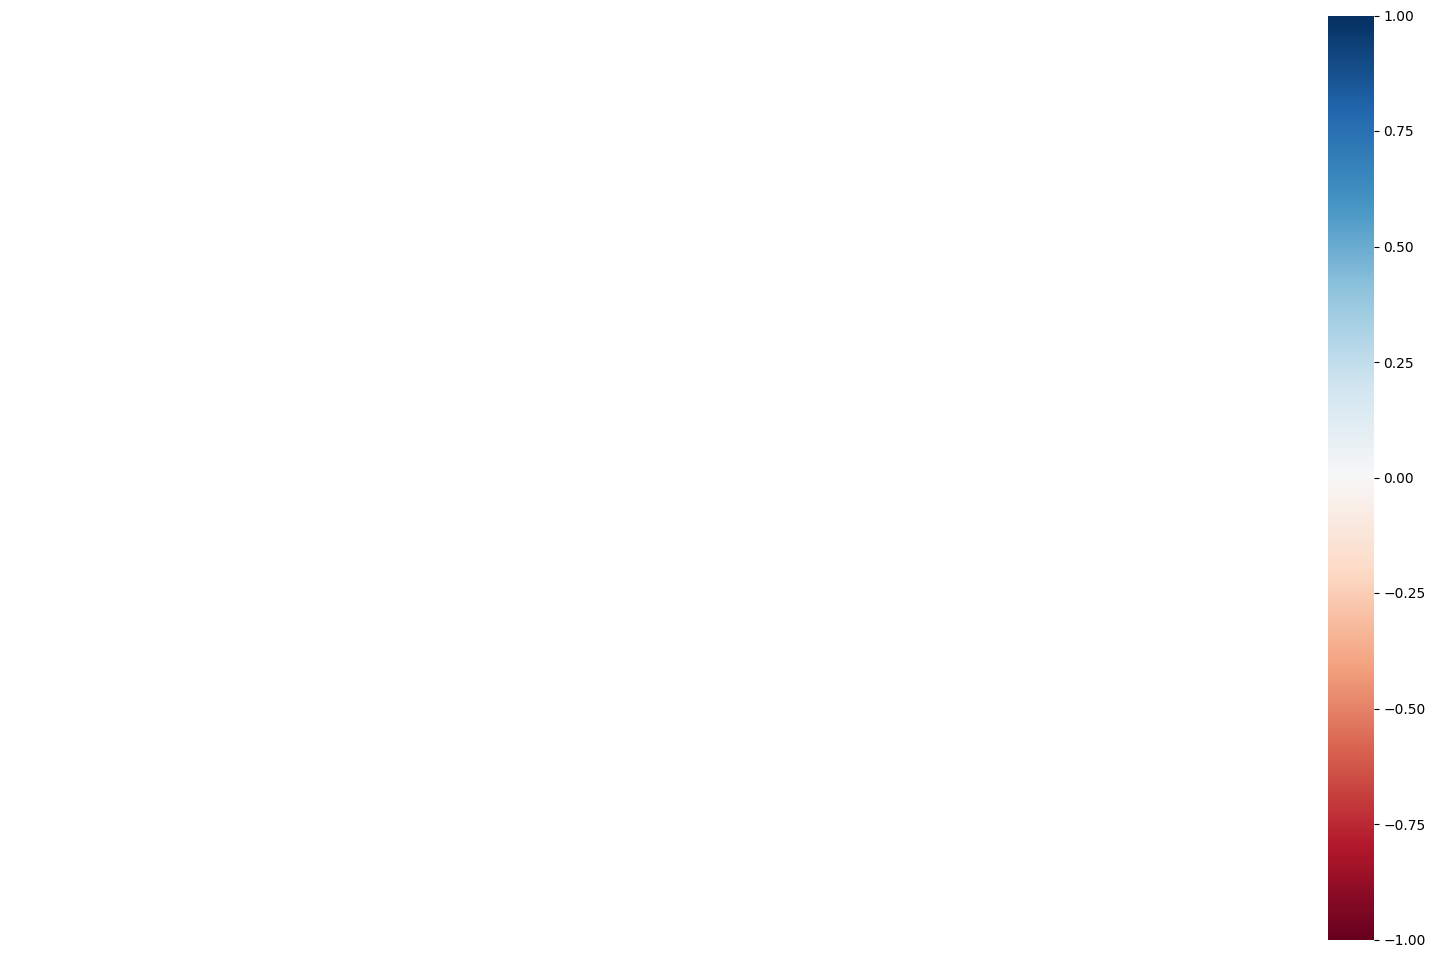

In [39]:
msno.heatmap(dali)     # Heatmap

In [ ]:
msno.dendrogram(pop)  # Dendrogram

# 4. Fusion  des dfs

In [30]:
df = pd.merge(
    pop,
    dali,
    on="Code Élément",   
    how="outer"          
)

print("Taille après fusion :", df.shape)



Taille après fusion : (181011, 28)


In [23]:
df.columns

Index(['Code Domaine_x', 'Domaine_x', 'Code zone_x', 'Zone_x', 'Code Élément',
       'Élément_x', 'Code Produit_x', 'Produit_x', 'Code année_x', 'Année_x',
       'Unité_x', 'Valeur_x', 'Symbole_x', 'Description du Symbole_x', 'Note',
       'Code Domaine_y', 'Domaine_y', 'Code zone_y', 'Zone_y', 'Élément_y',
       'Code Produit_y', 'Produit_y', 'Code année_y', 'Année_y', 'Unité_y',
       'Valeur_y', 'Symbole_y', 'Description du Symbole_y'],
      dtype='object')

In [31]:
display(df.head())

,Code Domaine_x,Domaine_x,Code zone_x,Zone_x,Code Élément,Élément_x,Code Produit_x,Produit_x,Code année_x,Année_x,...,Zone_y,Élément_y,Code Produit_y,Produit_y,Code année_y,Année_y,Unité_y,Valeur_y,Symbole_y,Description du Symbole_y
0,OA,Séries temporelles annuelles,2.0,Afghanistan,511,Population totale,3010.0,Population-Estimations,2000.0,2000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OA,Séries temporelles annuelles,2.0,Afghanistan,511,Population totale,3010.0,Population-Estimations,2001.0,2001.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OA,Séries temporelles annuelles,2.0,Afghanistan,511,Population totale,3010.0,Population-Estimations,2002.0,2002.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,OA,Séries temporelles annuelles,2.0,Afghanistan,511,Population totale,3010.0,Population-Estimations,2003.0,2003.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OA,Séries temporelles annuelles,2.0,Afghanistan,511,Population totale,3010.0,Population-Estimations,2004.0,2004.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
